❌ Không tìm thấy file, dùng data demo...
label
REAL    6
FAKE    6
Name: count, dtype: int64

Train: 8 | Test: 4
✅ Train xong!

Accuracy : 1.0000
ROC-AUC  : 1.0000
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00         2
        REAL       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



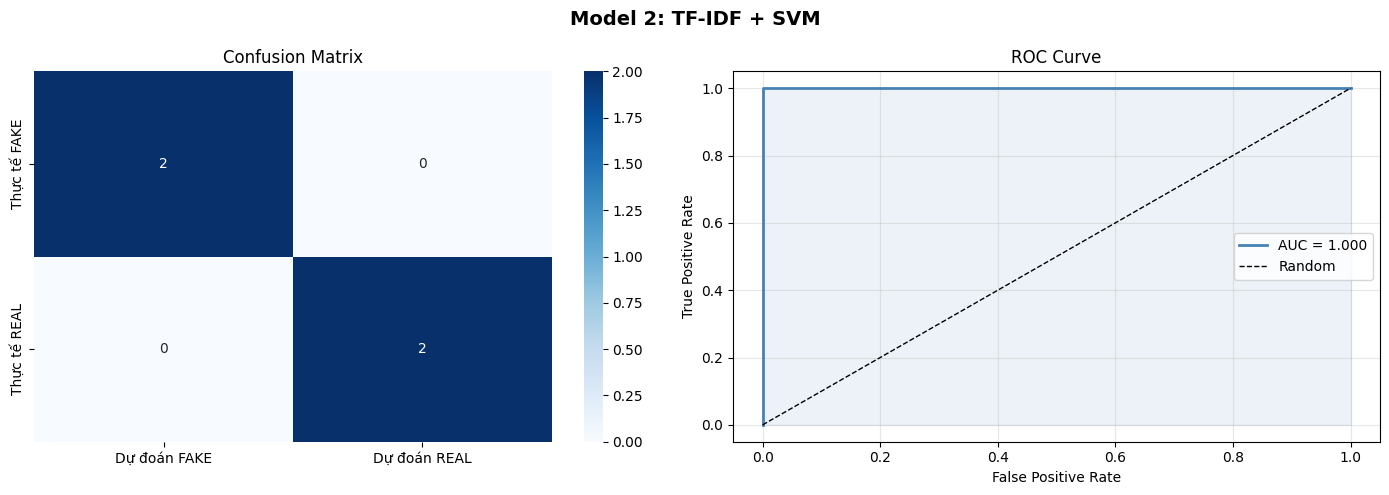


🟢 Top 10 từ đặc trưng cho REAL:
   toàn                            0.2889
   vaccine                         0.2889
   an                              0.2889
   an toàn                         0.2889
   who                             0.1706
   who tổ                          0.1706
   vaccine an                      0.1706
   vaccine covid                   0.1706
   tế thế                          0.1706
   tổ                              0.1706

🔴 Top 10 từ đặc trưng cho FAKE:
   chữa covid                      -0.3277
   chữa                            -0.3277
   bí quyết                        -0.1935
   bí                              -0.1935
   covid chuyên                    -0.1935
   covid thuốc                     -0.1935
   chuyên gia                      -0.1935
   chuyên                          -0.1935
   gia                             -0.1935
   gia tiết                        -0.1935

Cross-validation F1 (5-fold): 1.0000 ± 0.0000

✅ REAL  (REAL: 78.7% | FAKE: 21.3%)


In [4]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

try:
    from underthesea import word_tokenize
    USE_UNDERTHESEA = True
except ImportError:
    USE_UNDERTHESEA = False


# ── ĐỌC DỮ LIỆU ─────────────────────────────────────────
DATA_PATH = "Data_mẫu.xlsx"  # đổi thành file thật của nhóm

try:
    df = pd.read_excel(DATA_PATH) if DATA_PATH.endswith(".xlsx") else pd.read_csv(DATA_PATH)
    print(f"✅ Đọc thành công: {len(df)} dòng")
except FileNotFoundError:
    print("❌ Không tìm thấy file, dùng data demo...")
    df = pd.DataFrame({
        "title":   ["Vaccine Covid an toàn theo WHO"] * 6 + ["Uống nước muối chữa Covid"] * 6,
        "content": ["Tổ chức Y tế Thế giới khẳng định vaccine an toàn hiệu quả"] * 6 +
                   ["Chuyên gia tiết lộ bí quyết chữa covid không cần thuốc"] * 6,
        "label":   ["REAL"] * 6 + ["FAKE"] * 6
    })

print(df["label"].value_counts())


# ── TIỀN XỬ LÝ ───────────────────────────────────────────
STOPWORDS_VI = {
    "và", "của", "là", "có", "trong", "được", "cho", "với", "này",
    "đã", "các", "một", "để", "không", "về", "từ", "theo", "tại",
    "khi", "đó", "những", "do", "hay", "thì", "mà", "vì", "như",
    "cũng", "còn", "rất", "đây", "bởi", "vào", "ra", "lên", "xuống",
    "sau", "trước", "nếu", "nhưng", "hoặc", "đến", "tới", "hơn",
    "nhất", "nữa", "thêm", "đang", "sẽ", "phải", "cần", "đều",
}

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\w\sàáâãèéêìíòóôõùúýăđơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ]", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

def tokenize_vi(text):
    tokens = word_tokenize(text, format="text").split() if USE_UNDERTHESEA else text.split()
    return " ".join(t for t in tokens if t not in STOPWORDS_VI and len(t) > 1)

def preprocess(text):
    return tokenize_vi(clean_text(text))

# Ghép title + content → input chính cho model
df["text_processed"] = (df["title"].fillna("") + " " + df["content"].fillna("")).apply(preprocess)


# ── CHIA DỮ LIỆU ─────────────────────────────────────────
X = df["text_processed"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")


# ── XÂY DỰNG MODEL TF-IDF + SVM ──────────────────────────
# TF-IDF: chuyển text thành vector số (mỗi từ có trọng số theo mức độ đặc trưng)
# SVM: tìm siêu phẳng phân tách REAL vs FAKE tốt nhất
pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,  # giữ top 10k từ
        ngram_range=(1, 2),  # unigram + bigram
        sublinear_tf=True,   # dùng log(TF) thay TF thô
        min_df=1,
    )),
    ("svm", SVC(
        kernel="linear",          # kernel tuyến tính phù hợp với text
        C=1.0,                    # điều chỉnh độ rộng margin
        probability=True,         # cần để tính ROC-AUC
        class_weight="balanced",  # xử lý mất cân bằng nhãn
        random_state=42,
    ))
])

pipeline_svm.fit(X_train, y_train)
print("✅ Train xong!")


# ── ĐÁNH GIÁ ─────────────────────────────────────────────
y_pred  = pipeline_svm.predict(X_test)
y_proba = pipeline_svm.predict_proba(X_test)[:, 1]

le = LabelEncoder()
y_test_enc = le.fit_transform(y_test)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test_enc, y_proba)

print(f"\nAccuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))


# ── VẼ BIỂU ĐỒ ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model 2: TF-IDF + SVM", fontsize=14, fontweight="bold")

cm = confusion_matrix(y_test, y_pred, labels=["FAKE", "REAL"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán FAKE", "Dự đoán REAL"],
            yticklabels=["Thực tế FAKE", "Thực tế REAL"], ax=axes[0])
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test_enc, y_proba)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0,1], [0,1], "k--", lw=1, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model2_svm_results.png", dpi=150, bbox_inches="tight")
plt.show()


# ── TOP TỪ QUAN TRỌNG ────────────────────────────────────
# coef_ dương → đặc trưng REAL, coef_ âm → đặc trưng FAKE
feature_names = pipeline_svm.named_steps["tfidf"].get_feature_names_out()
coef_raw = pipeline_svm.named_steps["svm"].coef_
coefs = coef_raw.toarray()[0] if hasattr(coef_raw, "toarray") else np.array(coef_raw).flatten()

top_n = 10
print(f"\n🟢 Top {top_n} từ đặc trưng cho REAL:")
for idx in np.argsort(coefs)[-top_n:][::-1]:
    print(f"   {feature_names[idx]:30s}  {coefs[idx]:.4f}")

print(f"\n🔴 Top {top_n} từ đặc trưng cho FAKE:")
for idx in np.argsort(coefs)[:top_n]:
    print(f"   {feature_names[idx]:30s}  {coefs[idx]:.4f}")


# ── CROSS-VALIDATION ─────────────────────────────────────
cv_scores = cross_val_score(pipeline_svm, X, y, cv=5, scoring="f1_macro")
print(f"\nCross-validation F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ── DỰ ĐOÁN BÀI MỚI ──────────────────────────────────────
def predict_news(title, content=""):
    processed = preprocess(title + " " + content)
    label = pipeline_svm.predict([processed])[0]
    proba = pipeline_svm.predict_proba([processed])[0]
    fake_prob = proba[list(pipeline_svm.classes_).index("FAKE")]
    real_prob = proba[list(pipeline_svm.classes_).index("REAL")]
    icon = "✅" if label == "REAL" else "🚨"
    print(f"\n{icon} {label}  (REAL: {real_prob*100:.1f}% | FAKE: {fake_prob*100:.1f}%)")
    print(f"   {title[:80]}")

predict_news(
    title="WHO xác nhận vaccine COVID-19 an toàn và hiệu quả",
    content="Tổ chức Y tế Thế giới công bố báo cáo vaccine ngăn ngừa tử vong hiệu quả."
)
predict_news(
    title="TIẾT LỘ: Uống nước chanh mỗi sáng chữa khỏi ung thư 100%!!!",
    content="Bí quyết từ thầy lang bí ẩn ở Tây Nguyên được giấu kín hàng chục năm."
)

print(f"""
┌─────────────────────────────────────────┐
│         MODEL 2: TF-IDF + SVM           │
├─────────────────────────────────────────┤
│  TF-IDF : 10k features, ngram (1,2)     │
│  SVM    : kernel=linear, C=1.0          │
│  Accuracy    : {acc:.4f}                    │
│  ROC-AUC     : {auc:.4f}                    │
│  CV F1-macro : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}            │
└─────────────────────────────────────────┘
""")